
# StarDist 3D model training

This notebook  was obtained from the [StarDist](https://github.com/stardist/stardist) 
repository for 3D nuclear segmentation.

## Original Source
The core StarDist implementation and example notebooks are from:
- GitHub: https://github.com/stardist/stardist
- Paper: Schmidt, U., Weigert, M., Broaddus, C., & Myers, G. (2018). 
  Cell Detection with Star-convex Polygons. 
  International Conference on Medical Image Computing and Computer-Assisted Intervention (MICCAI).
## License
StarDist is released under the BSD 3-Clause License.
See: https://github.com/stardist/stardist/blob/master/LICENSE.txt

In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import matplotlib
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from glob import glob
from tqdm import tqdm
from tifffile import imread
from csbdeep.utils import Path, normalize

from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist import Rays_GoldenSpiral
from stardist.matching import matching, matching_dataset
from stardist.models import Config3D, StarDist3D, StarDistData3D

np.random.seed(42)
lbl_cmap = random_label_cmap()
import tensorflow as tf


bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
X = sorted(glob('C:/Users/josed/Desktop/StarDIST_Training/CROP/CROP_RAW/*.tif'))
Y = sorted(glob('C:/Users/josed/Desktop/StarDIST_Training/CROP/CROP_MASKS/*.tif'))
assert all(Path(x).name==Path(y).name for x,y in zip(X,Y))

In [3]:
X = list(map(imread,X))
Y = list(map(imread,Y))
n_channel = 1 if X[0].ndim == 3 else X[0].shape[-1]

In [4]:
axis_norm = (0,1,2)   # normalize channels independently
# axis_norm = (0,1,2,3) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 3 in axis_norm else 'independently'))
    sys.stdout.flush()

X = [normalize(x,1,99.8,axis=axis_norm) for x in tqdm(X)]
Y = [fill_label_holes(y) for y in tqdm(Y)]

100%|████████████████████████████████████████████████████████████████████████████████| 122/122 [00:01<00:00, 86.00it/s]


In [5]:
assert len(X) > 1, "not enough training data"
rng = np.random.RandomState(42)
ind = rng.permutation(len(X))
n_val = max(1, int(round(0.15 * len(ind))))
ind_train, ind_val = ind[:-n_val], ind[-n_val:]
X_val, Y_val = [X[i] for i in ind_val]  , [Y[i] for i in ind_val]
X_trn, Y_trn = [X[i] for i in ind_train], [Y[i] for i in ind_train] 
print('number of images: %3d' % len(X))
print('- training:       %3d' % len(X_trn))
print('- validation:     %3d' % len(X_val))

number of images: 122
- training:       104
- validation:      18


In [6]:
def plot_img_label(img, lbl, img_title="image (XY slice)", lbl_title="label (XY slice)", z=None, **kwargs):
    if z is None:
        z = img.shape[0] // 2    
    fig, (ai,al) = plt.subplots(1,2, figsize=(12,5), gridspec_kw=dict(width_ratios=(1.25,1)))
    im = ai.imshow(img[z], cmap='gray', clim=(0,1))
    ai.set_title(img_title)    
    fig.colorbar(im, ax=ai)
    al.imshow(lbl[z], cmap=lbl_cmap)
    al.set_title(lbl_title)
    plt.tight_layout()

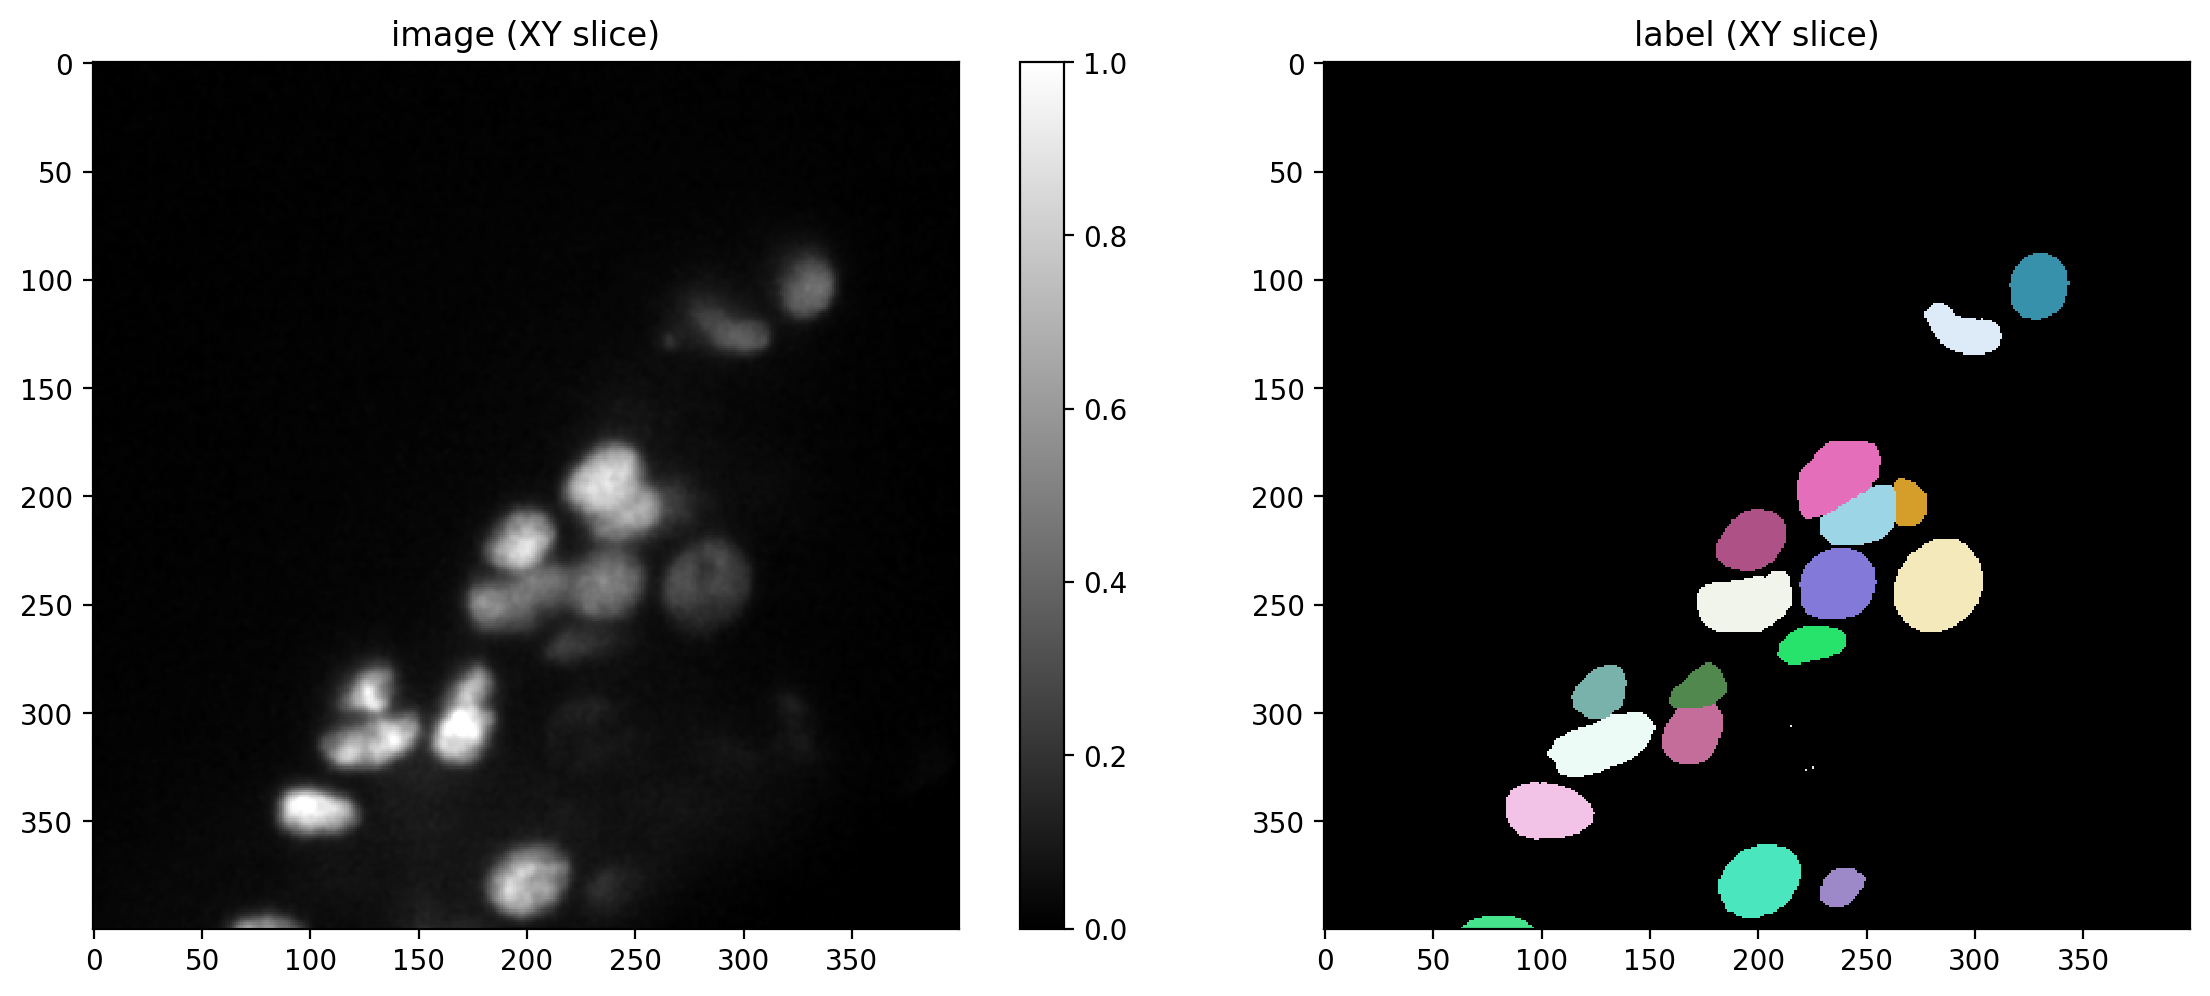

In [7]:
i = 0
img, lbl = X[i], Y[i]
assert img.ndim in (3,4)
img = img if img.ndim==3 else img[...,:3]
plot_img_label(img,lbl)
None;

In [8]:
extents = calculate_extents(Y)
anisotropy = tuple(np.max(extents) / extents)
print('empirical anisotropy of labeled objects = %s' % str(anisotropy))

empirical anisotropy of labeled objects = (7.818181818181818, 1.0, 1.0817610062893082)


In [9]:
# 96 is a good default choice (see 1_data.ipynb)
n_rays = 96

# Use OpenCL-based computations for data generator during training (requires 'gputools')
use_gpu =gputools_available(),

# Predict on subsampled grid for increased efficiency and larger field of view
grid = tuple(1 if a > 1.5 else 2 for a in anisotropy)

# Use rays on a Fibonacci lattice adjusted for measured anisotropy of the training data
rays = Rays_GoldenSpiral(n_rays, anisotropy=anisotropy)

conf = Config3D (
    rays             = rays,
    grid             = grid,
    anisotropy       = anisotropy,
    use_gpu =  True and gputools_available(),
    n_channel_in     = n_channel,
    # adjust for your data below (make patch size as large as possible)
    train_patch_size = (10,400,400),
    train_batch_size = 2,
)
print(conf)
vars(conf)

Config3D(n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=97, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=96, grid=(1, 2, 2), anisotropy=(7.818181818181818, 1.0, 1.0817610062893082), backbone='unet', rays_json={'name': 'Rays_GoldenSpiral', 'kwargs': {'n': 96, 'anisotropy': (7.818181818181818, 1.0, 1.0817610062893082)}}, n_classes=None, unet_n_depth=2, unet_kernel_size=(3, 3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=(2, 2, 2), unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, None, 1), net_mask_shape=(None, None, None, 1), train_patch_size=(10, 400, 400), train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=400, train_steps_per_epoch=100, train_learning

{'n_dim': 3,
 'axes': 'ZYXC',
 'n_channel_in': 1,
 'n_channel_out': 97,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'n_rays': 96,
 'grid': (1, 2, 2),
 'anisotropy': (7.818181818181818, 1.0, 1.0817610062893082),
 'backbone': 'unet',
 'rays_json': {'name': 'Rays_GoldenSpiral',
  'kwargs': {'n': 96,
   'anisotropy': (7.818181818181818, 1.0, 1.0817610062893082)}},
 'n_classes': None,
 'unet_n_depth': 2,
 'unet_kernel_size': (3, 3, 3),
 'unet_n_filter_base': 32,
 'unet_n_conv_per_depth': 2,
 'unet_pool': (2, 2, 2),
 'unet_activation': 'relu',
 'unet_last_activation': 'relu',
 'unet_batch_norm': False,
 'unet_dropout': 0.0,
 'unet_prefix': '',
 'net_conv_after_unet': 128,
 'net_input_shape': (None, None, None, 1),
 'net_mask_shape': (None, None, None, 1),
 'train_patch_size': (10, 400, 400),
 'train_background_reg': 0.0001,
 'train_foreground_only': 0.9,
 'train_sample_cache': True,
 'train_dist_loss': 'ma

In [10]:
model = StarDist3D(conf, name='stardistV2.7', basedir='models')

Using default values: prob_thresh=0.5, nms_thresh=0.4.


In [38]:
median_size = calculate_extents(Y, np.median)
fov = np.array(model._axes_tile_overlap('ZYX'))
print(f"median object size:      {median_size}")
print(f"network field of view :  {fov}")
if any(median_size > fov):
    print("WARNING: median object size larger than field of view of the neural network.")

median object size:      [ 5.5  43.   39.75]
network field of view :  [26 46 46]


In [39]:
def random_fliprot(img, mask, axis=None): 
    if axis is None:
        axis = tuple(range(mask.ndim))
    axis = tuple(axis)
            
    assert img.ndim>=mask.ndim
    perm = tuple(np.random.permutation(axis))
    transpose_axis = np.arange(mask.ndim)
    for a, p in zip(axis, perm):
        transpose_axis[a] = p
    transpose_axis = tuple(transpose_axis)
    img = img.transpose(transpose_axis + tuple(range(mask.ndim, img.ndim))) 
    mask = mask.transpose(transpose_axis) 
    for ax in axis: 
        if np.random.rand() > 0.5:
            img = np.flip(img, axis=ax)
            mask = np.flip(mask, axis=ax)
    return img, mask 

def random_intensity_change(img):
    img = img*np.random.uniform(0.6,2) + np.random.uniform(-0.2,0.2)
    return img

def augmenter(x, y):
    """Augmentation of a single input/label image pair.
    x is an input image
    y is the corresponding ground-truth label image
    """
    # Note that we only use fliprots along axis=(1,2), i.e. the yx axis 
    # as 3D microscopy acquisitions are usually not axially symmetric
    x, y = random_fliprot(x, y, axis=(1,2))
    x = random_intensity_change(x)
    return x, y

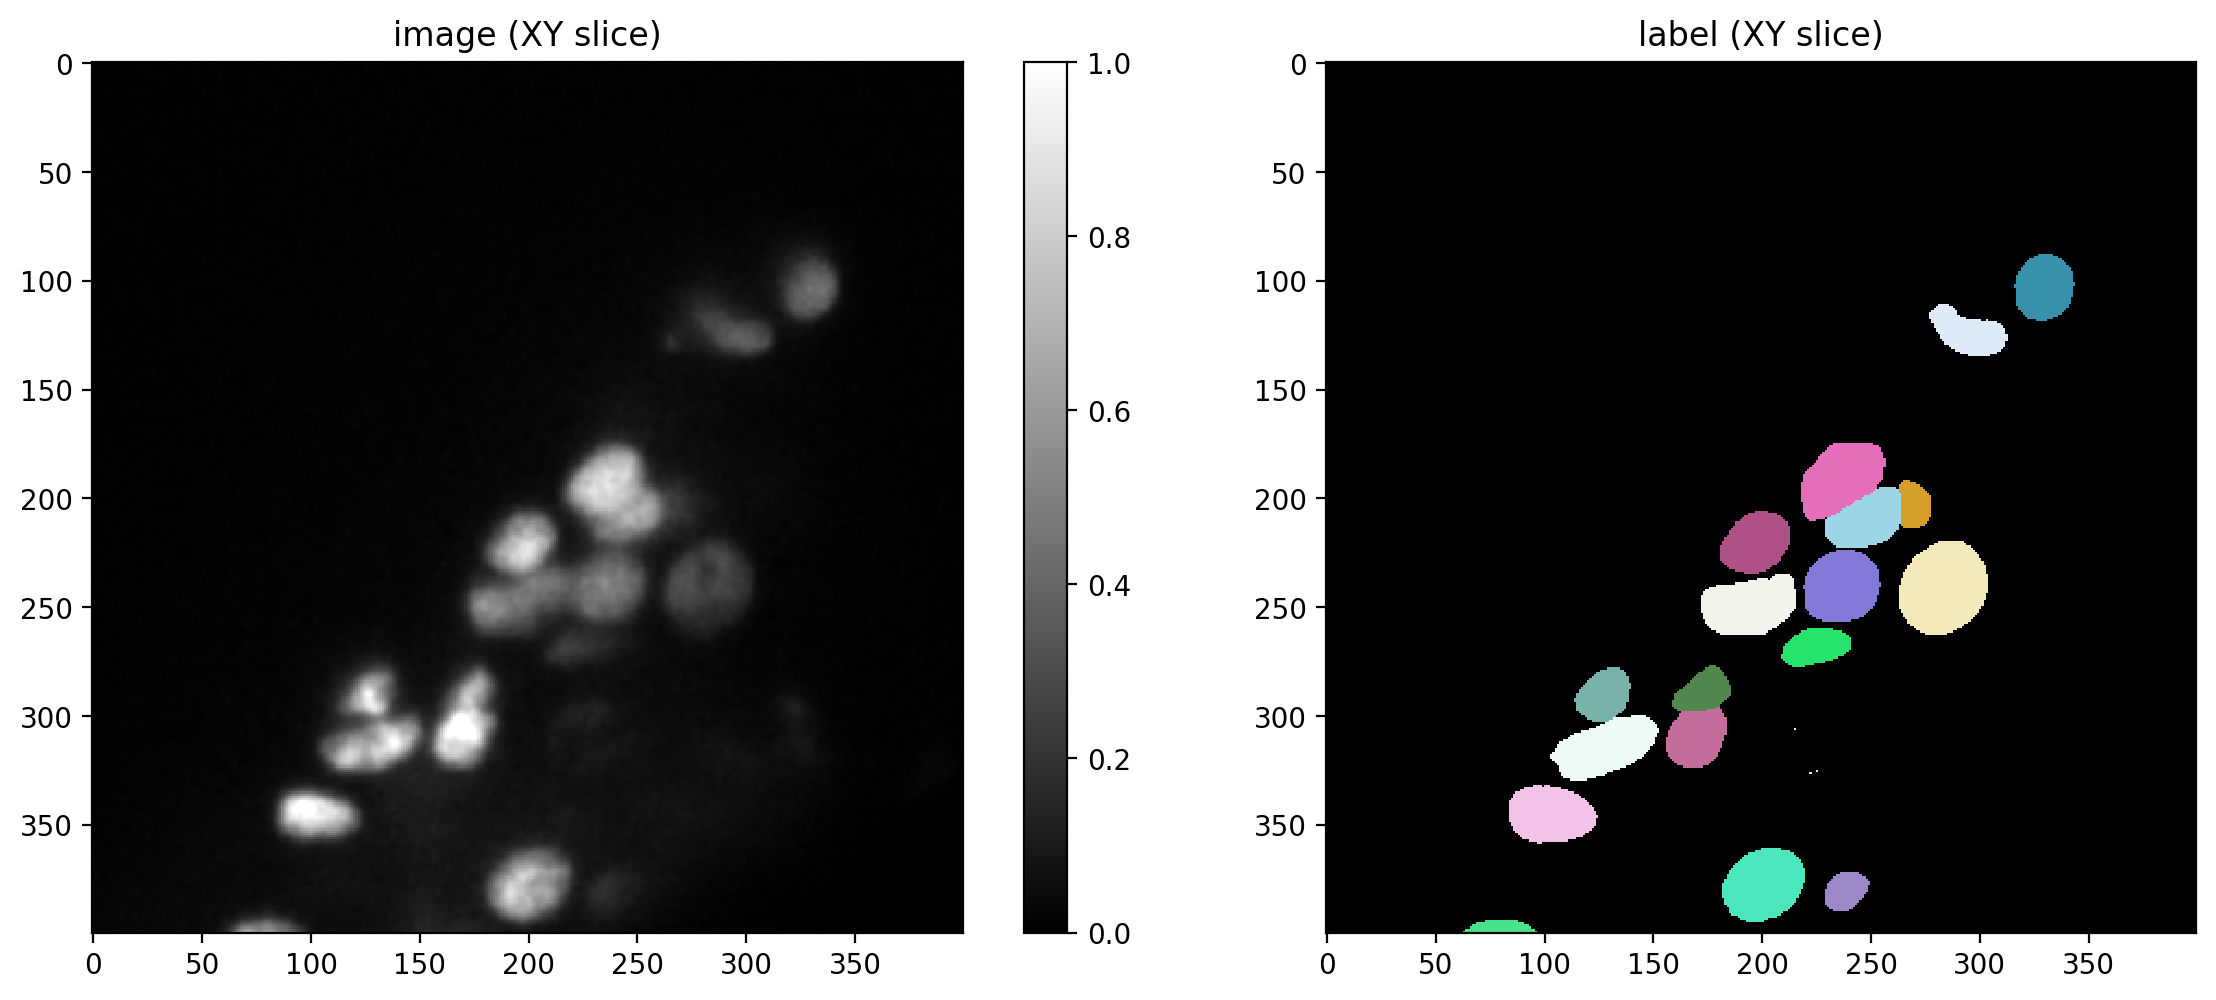

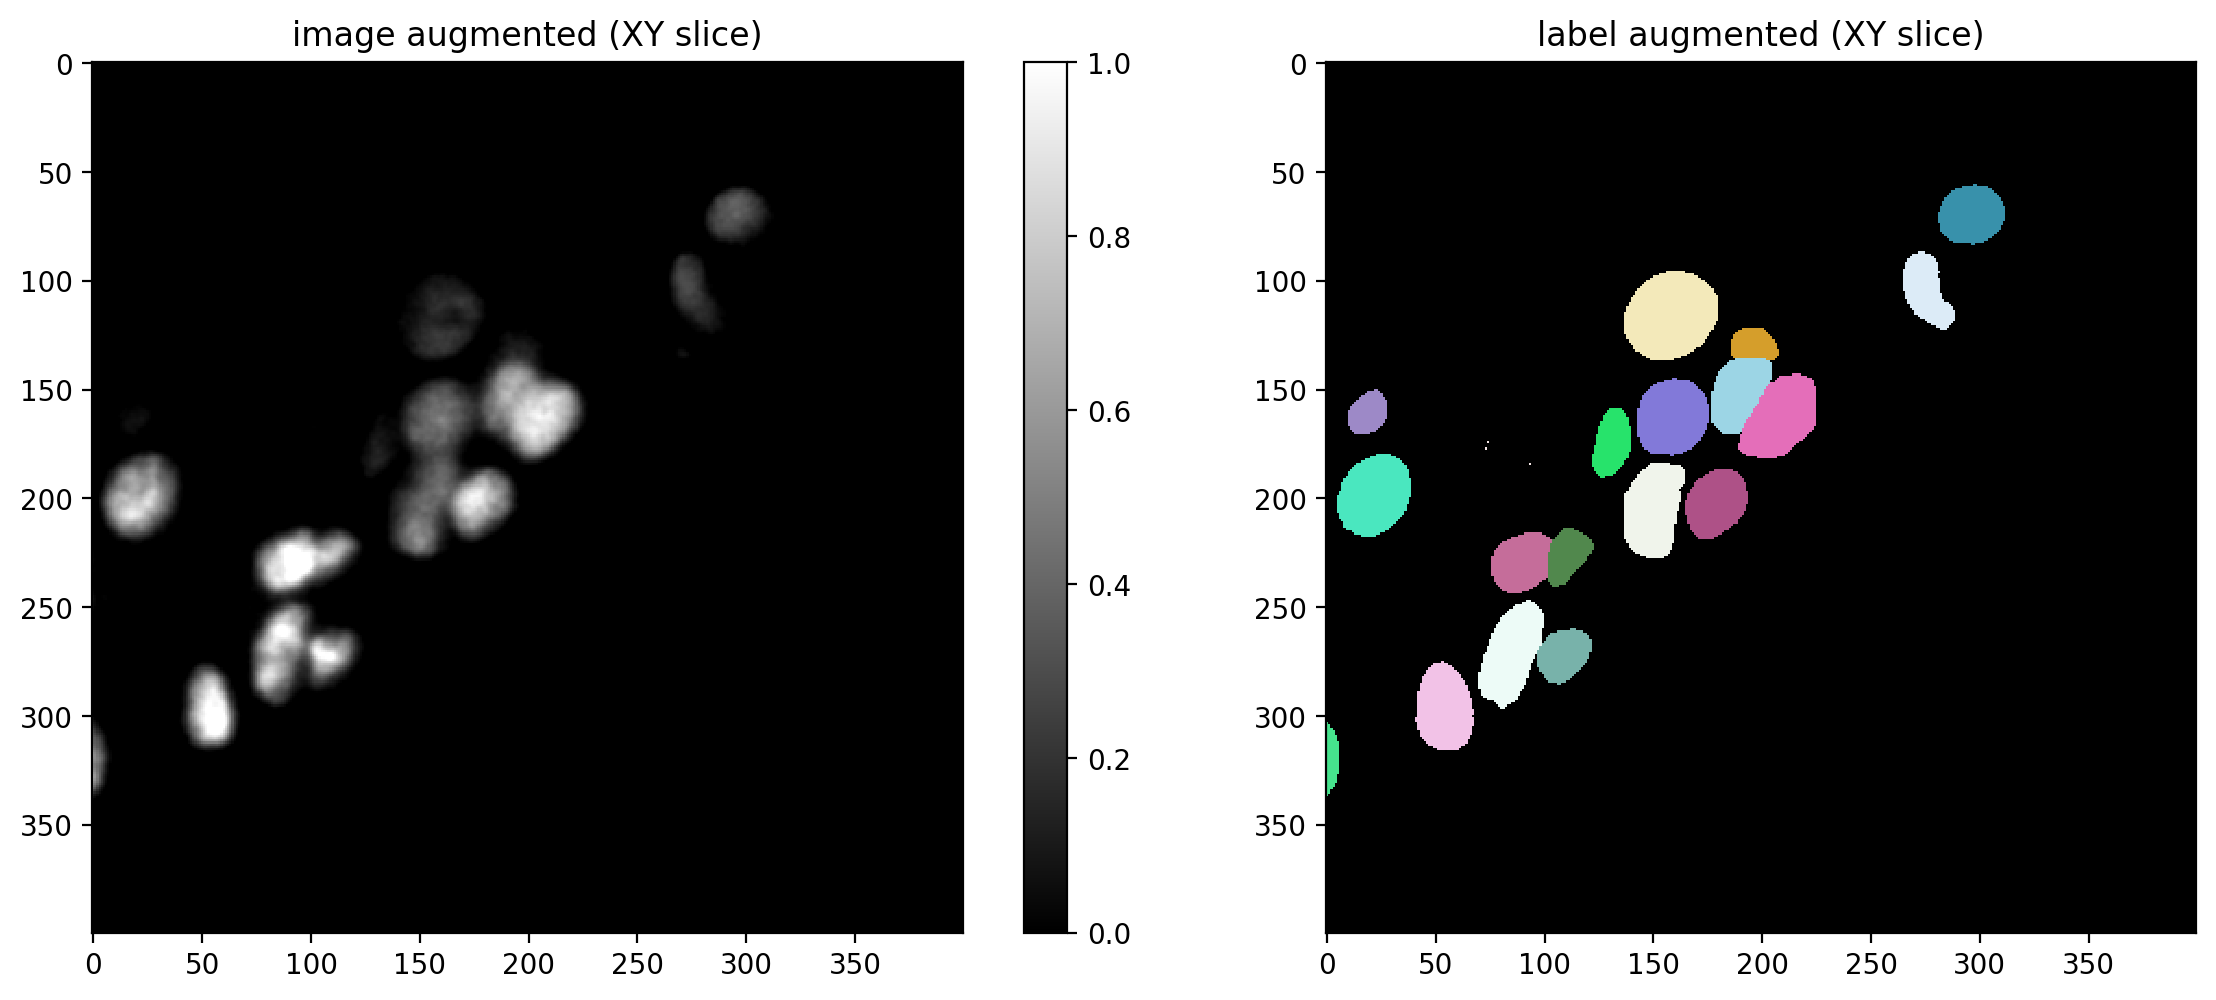

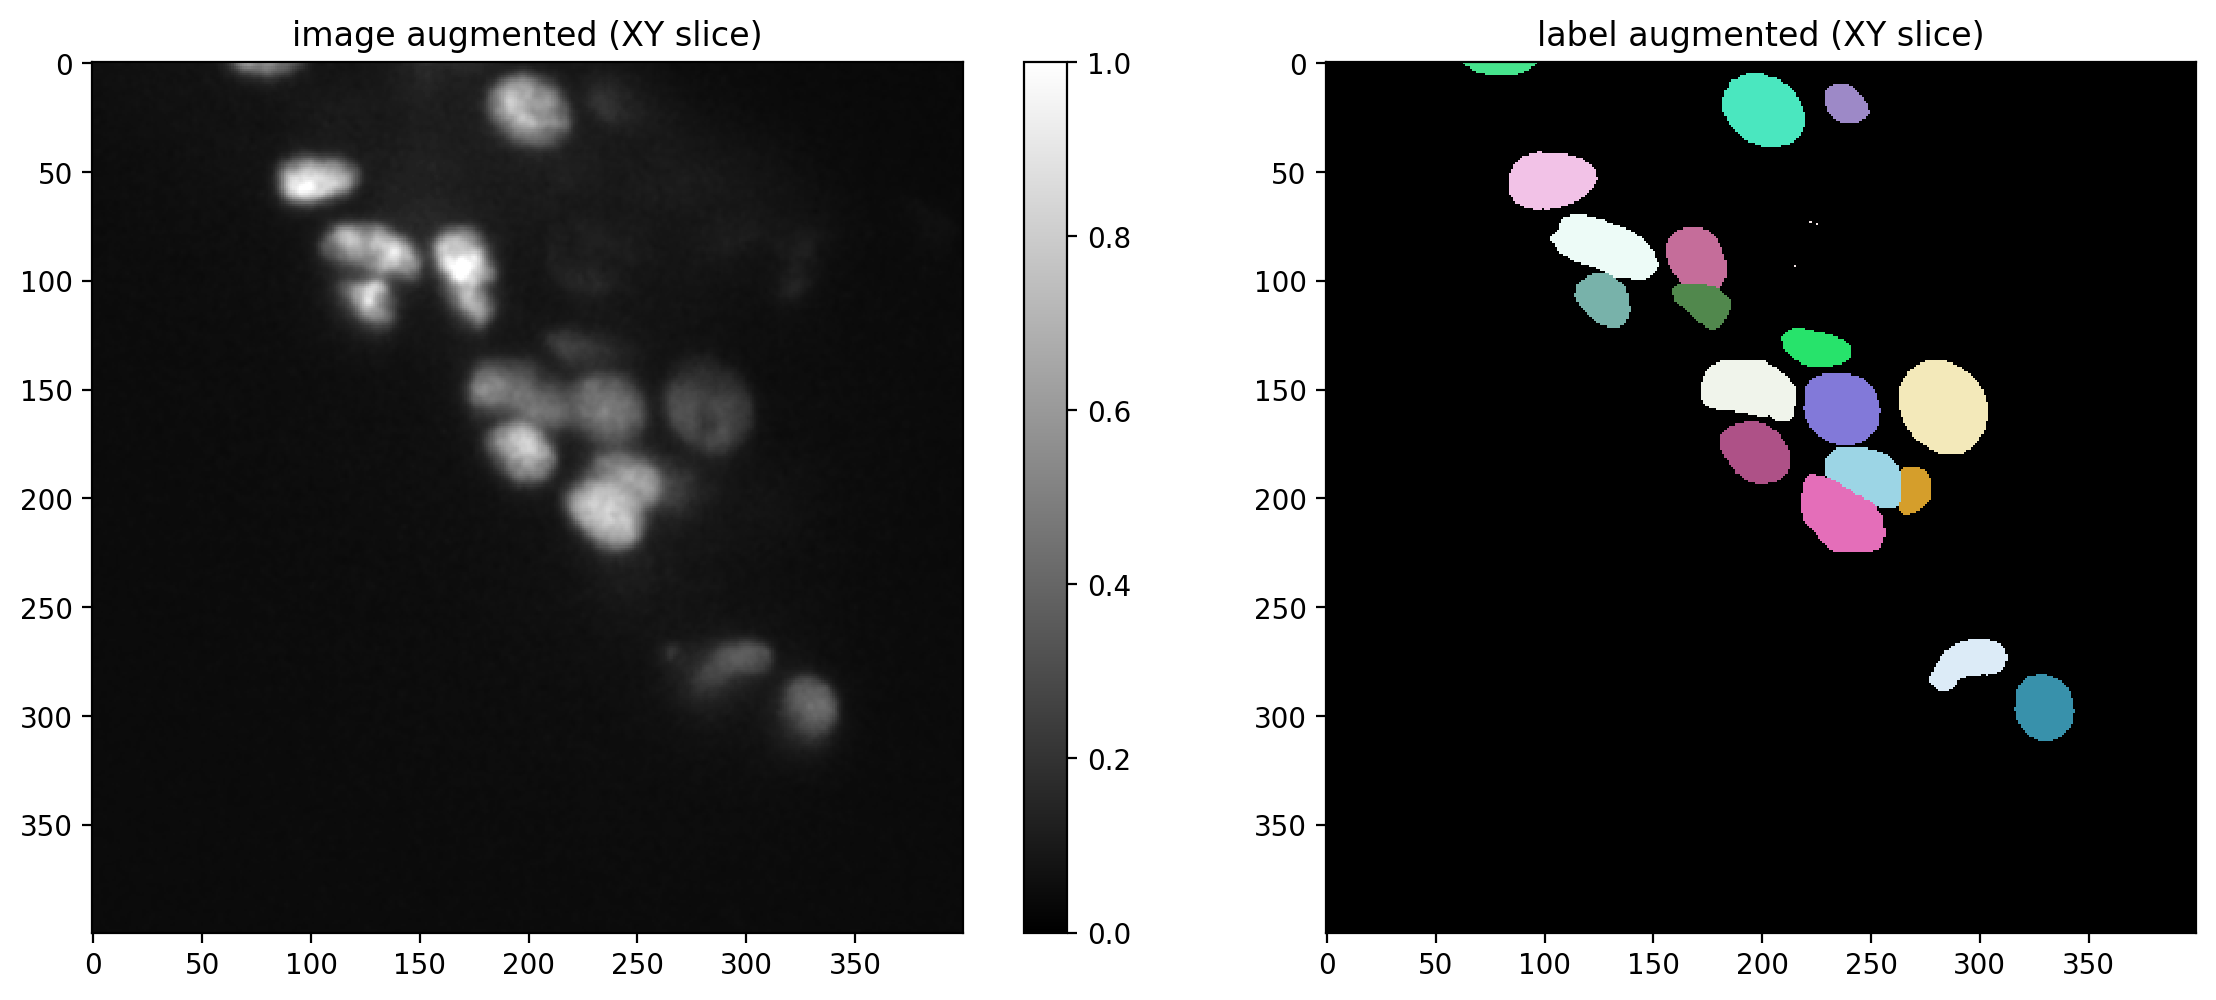

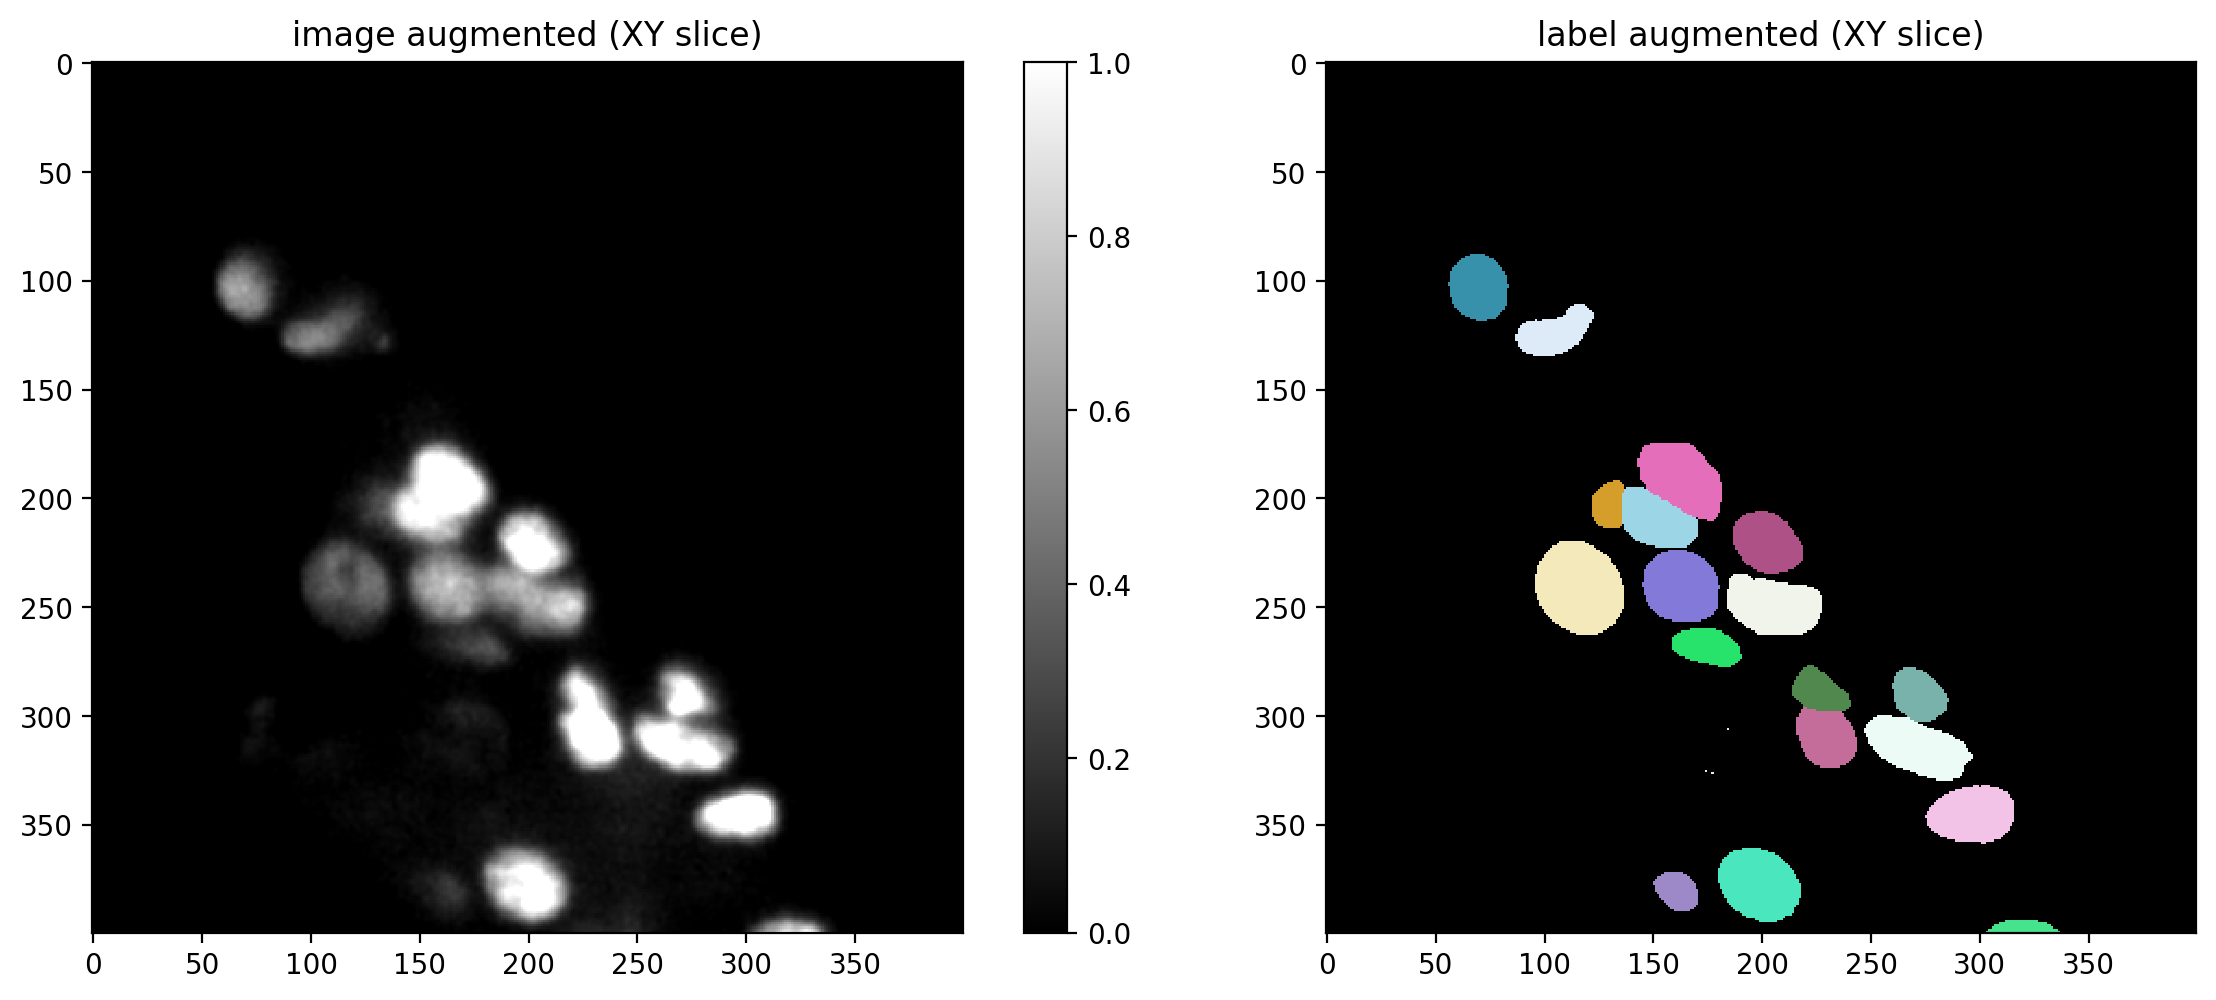

In [40]:
# plot some augmented examples
img, lbl = X[0],Y[0]
plot_img_label(img, lbl)
for _ in range(3):
    img_aug, lbl_aug = augmenter(img,lbl)
    plot_img_label(img_aug, lbl_aug, img_title="image augmented (XY slice)", lbl_title="label augmented (XY slice)")

In [41]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 13823631560989109609
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14668529664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 13347153024309863212
physical_device_desc: "device: 0, name: Quadro RTX 5000, pci bus id: 0000:04:00.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [17]:
 model.train(X_trn, Y_trn, validation_data=(X_val,Y_val), augmenter=augmenter,epochs= 400, steps_per_epoch=100)

Epoch 1/400
100/100 [==============================] - 170s 982ms/step - loss: 2.3380 - prob_loss: 0.3499 - dist_loss: 9.9404 - prob_kld: 0.3174 - dist_relevant_mae: 9.9398 - dist_relevant_mse: 212.8335 - dist_dist_iou_metric: 0.1973 - val_loss: 1.8743 - val_prob_loss: 0.4216 - val_dist_loss: 7.2633 - val_prob_kld: 0.3804 - val_dist_relevant_mae: 7.2625 - val_dist_relevant_mse: 130.7962 - val_dist_dist_iou_metric: 0.3279 - lr: 3.0000e-04
Epoch 2/400
100/100 [==============================] - 406s 4s/step - loss: 1.7317 - prob_loss: 0.2063 - dist_loss: 7.6273 - prob_kld: 0.1729 - dist_relevant_mae: 7.6263 - dist_relevant_mse: 142.2167 - dist_dist_iou_metric: 0.3147 - val_loss: 1.5557 - val_prob_loss: 0.1453 - val_dist_loss: 7.0524 - val_prob_kld: 0.1040 - val_dist_relevant_mae: 7.0512 - val_dist_relevant_mse: 116.7136 - val_dist_dist_iou_metric: 0.3689 - lr: 3.0000e-04
Epoch 3/400
100/100 [==============================] - 72s 717ms/step - loss: 1.6407 - prob_loss: 0.1367 - dist_loss: 7

In [18]:
model.optimize_thresholds(X_val, Y_val)

NMS threshold = 0.5:  80%|███████████████████████████████████▏        | 16/20 [44:50<11:12, 168.16s/it, 0.438 -> 0.433]


Using optimized values: prob_thresh=0.436838, nms_thresh=0.3.
Saving to 'thresholds.json'.


{'prob': 0.4368380010128021, 'nms': 0.3}

In [19]:
Y_val_pred = [model.predict_instances(x, n_tiles=model._guess_n_tiles(x), show_tile_progress=False)[0]
              for x in tqdm(X_val)]

100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [06:04<00:00, 20.27s/it]


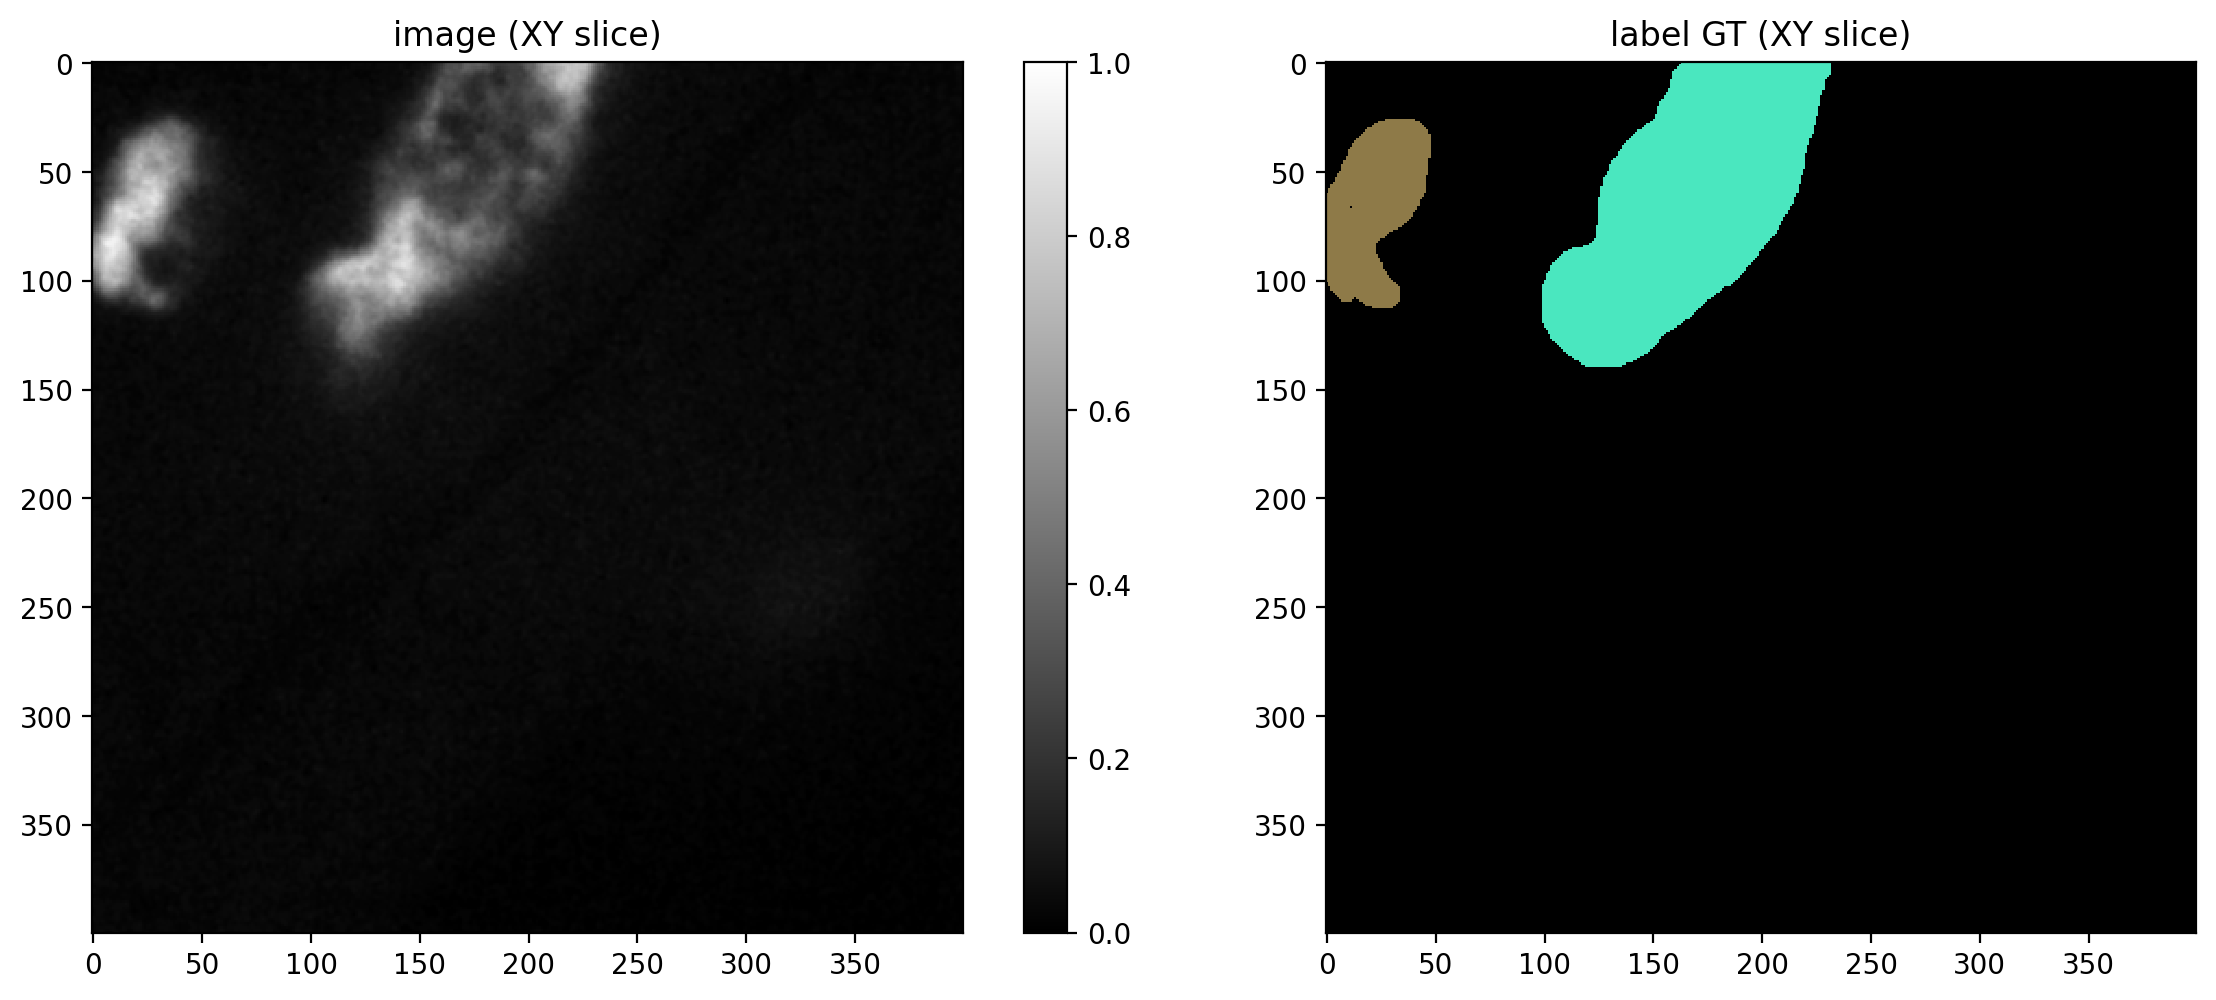

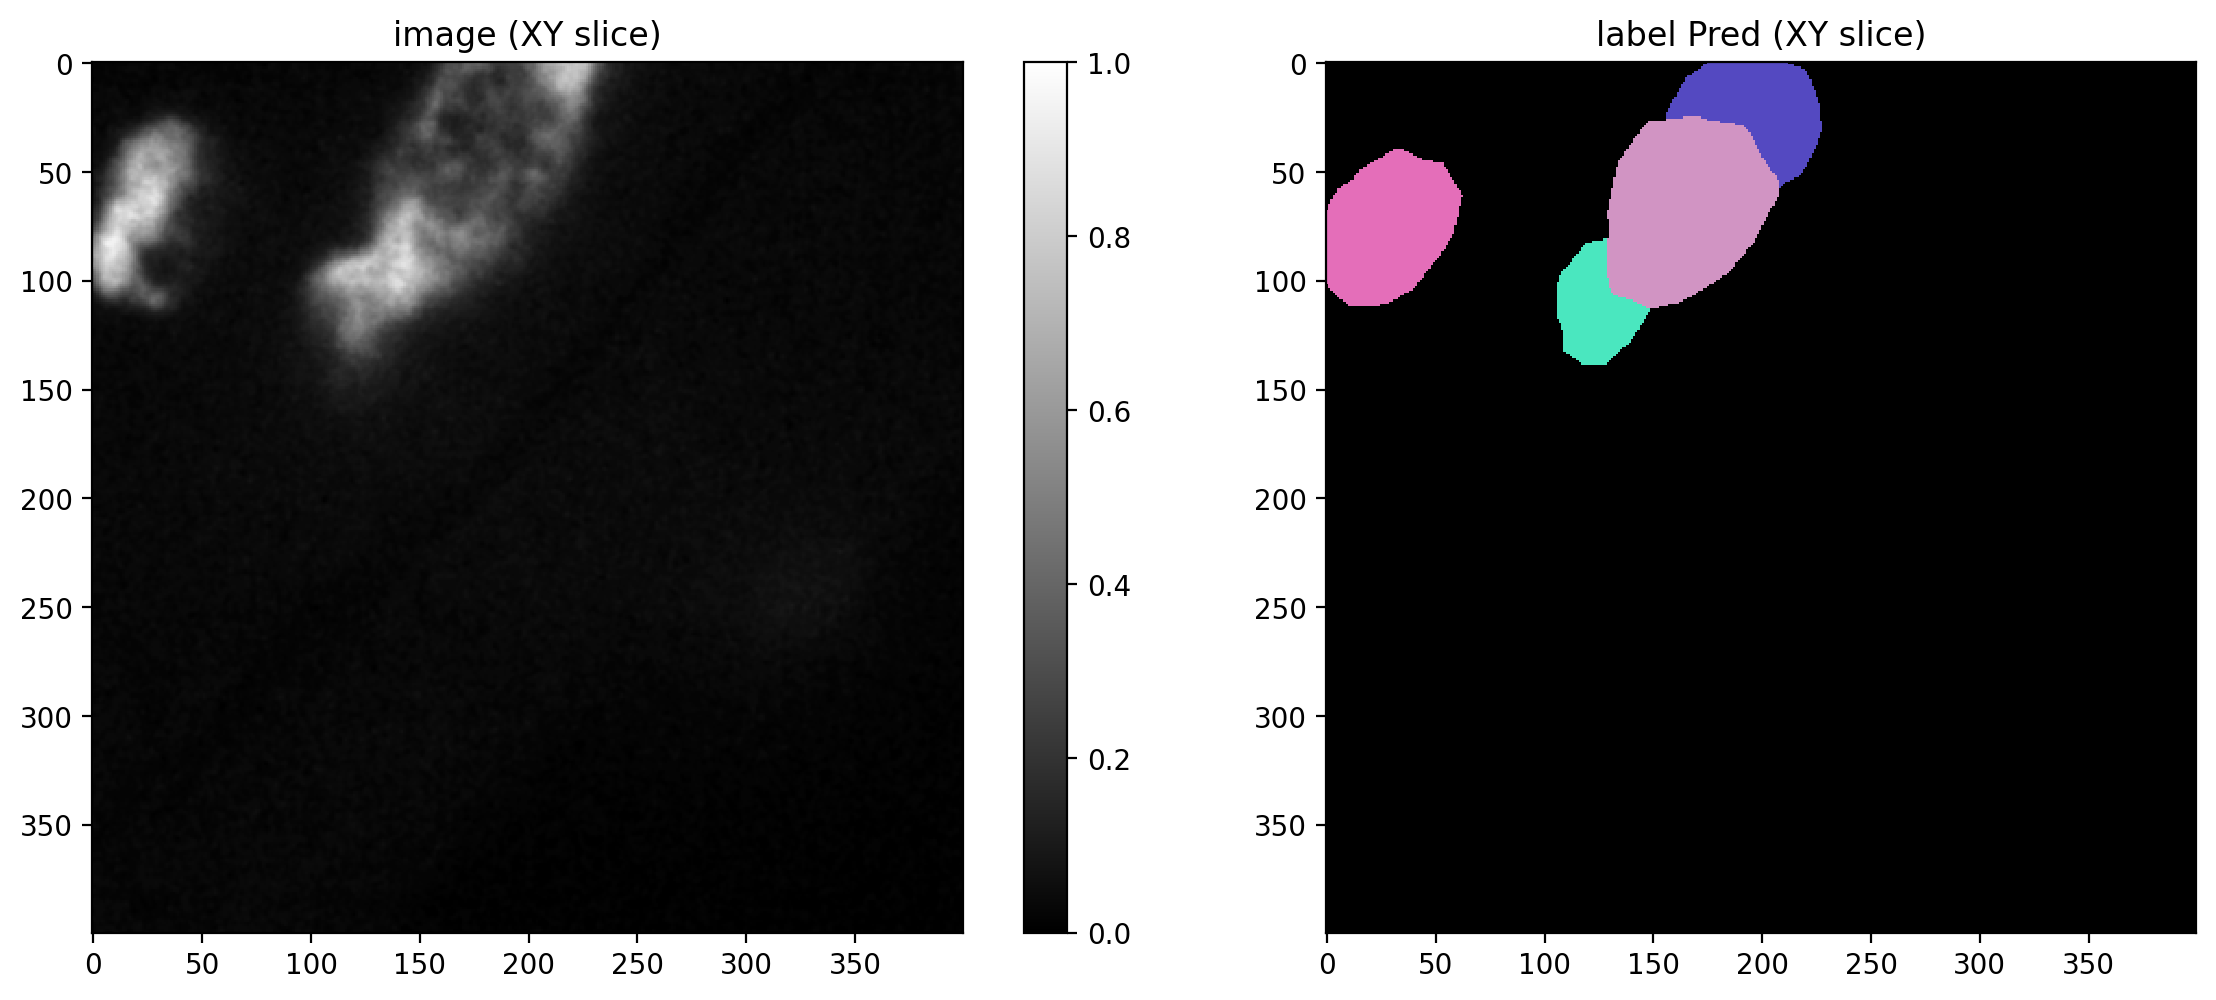

In [20]:
plot_img_label(X_val[1],Y_val[1], lbl_title="label GT (XY slice)")
plot_img_label(X_val[1],Y_val_pred[1], lbl_title="label Pred (XY slice)")

In [21]:
taus = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
stats = [matching_dataset(Y_val, Y_val_pred, thresh=t, show_progress=False) for t in tqdm(taus)]

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:06<00:00,  1.49it/s]


In [22]:
stats[taus.index(0.7)]

DatasetMatching(criterion='iou', thresh=0.7, fp=290, tp=150, fn=369, precision=0.3409090909090909, recall=0.28901734104046245, accuracy=0.18541409147095178, f1=0.31282586027111575, n_true=519, n_pred=440, mean_true_score=0.21825813649936449, mean_matched_score=0.7551731522878011, panoptic_quality=0.23623769101808167, by_image=False)

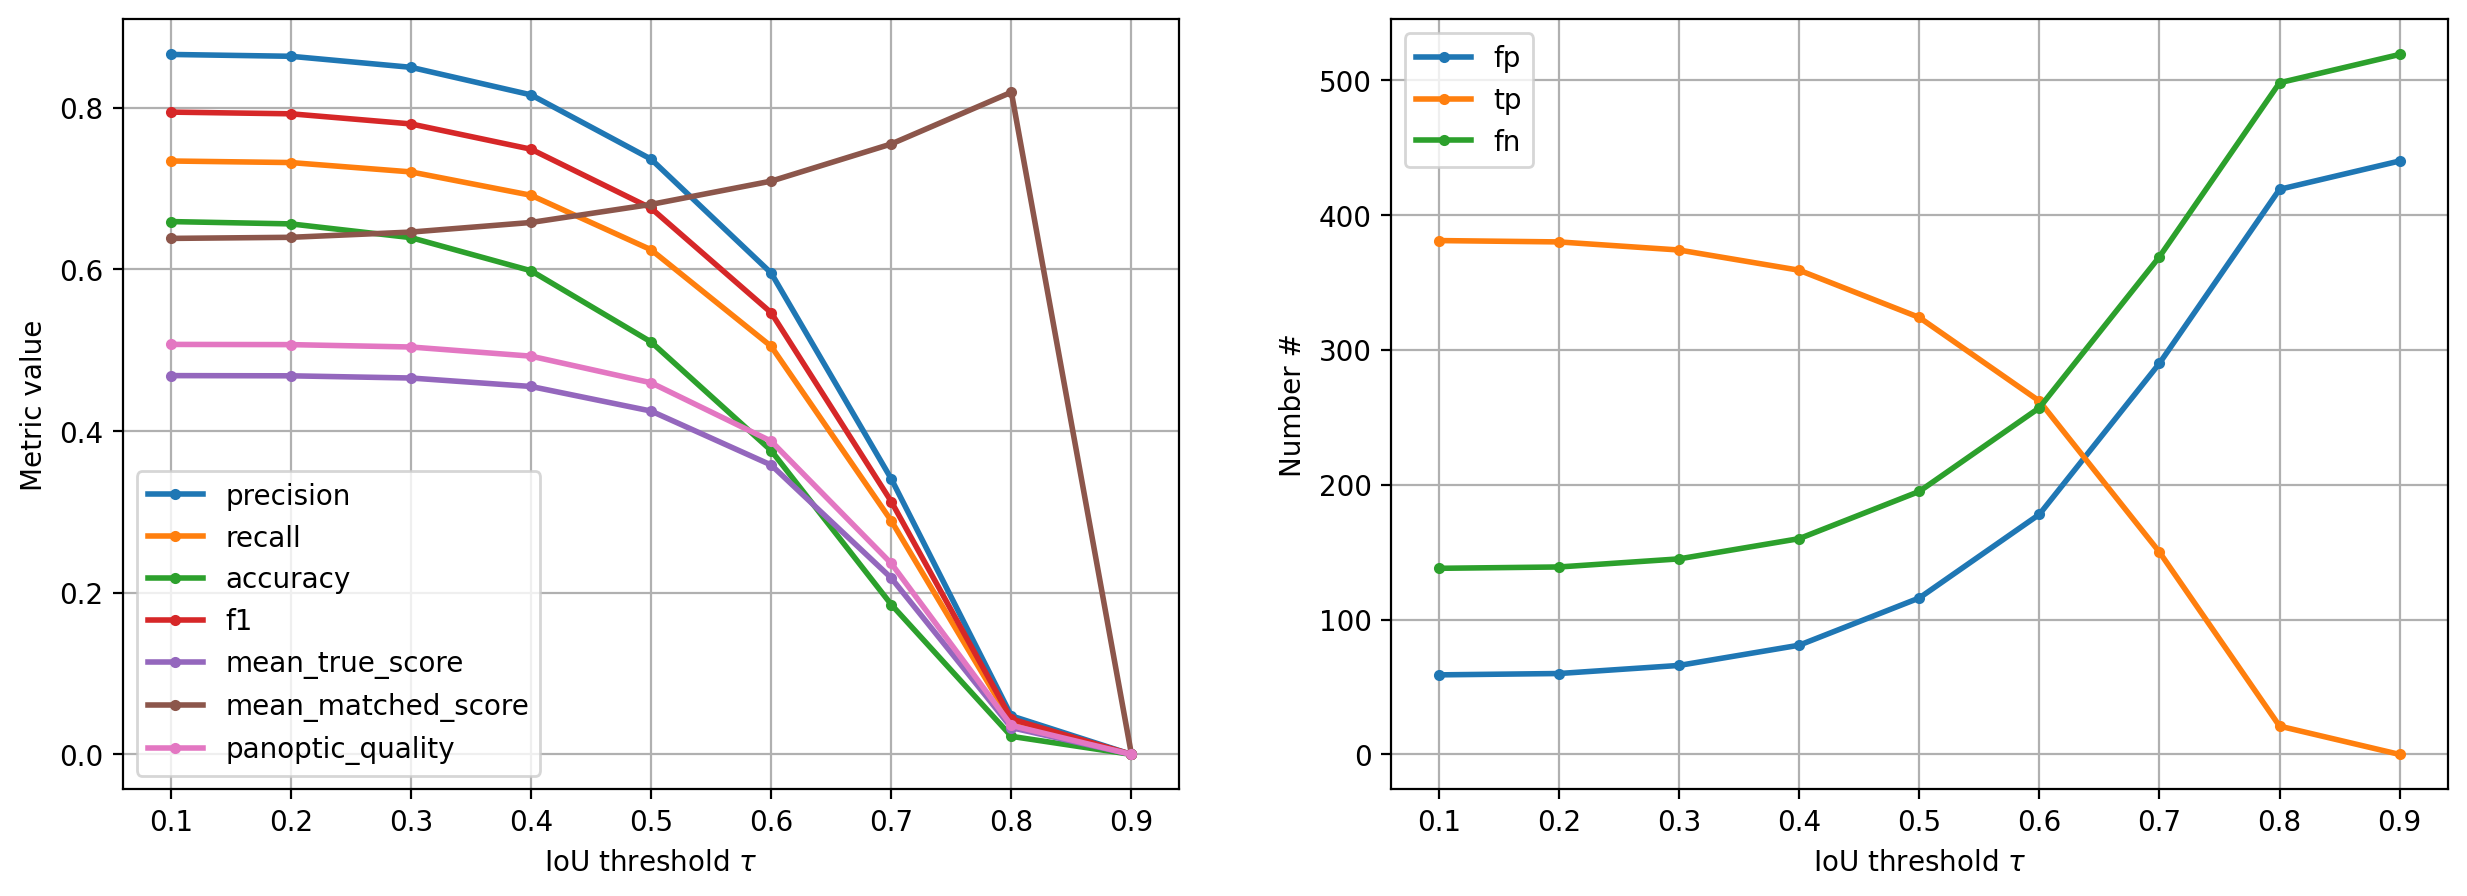

In [24]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15,5))

for m in ('precision', 'recall', 'accuracy', 'f1', 'mean_true_score', 'mean_matched_score', 'panoptic_quality'):
    ax1.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
ax1.set_xlabel(r'IoU threshold $\tau$')
ax1.set_ylabel('Metric value')
ax1.grid()
ax1.legend()

for m in ('fp', 'tp', 'fn'):
    ax2.plot(taus, [s._asdict()[m] for s in stats], '.-', lw=2, label=m)
ax2.set_xlabel(r'IoU threshold $\tau$')
ax2.set_ylabel('Number #')
ax2.grid()
ax2.legend();
